**clone github repository and create new branch**

In [1]:
! git clone https://github.com/mrosalia96/ADS504-Bank-Marketing.git

fatal: destination path 'ADS504-Bank-Marketing' already exists and is not an empty directory.


In [2]:
%cd /content/ADS504-Bank-Marketing

/content/ADS504-Bank-Marketing


In [3]:
!pwd

/content/ADS504-Bank-Marketing


In [4]:
!ls

ADS504-Bank-Marketing  data  notebooks	README.md


In [5]:
!git branch -a

  main
* modeling
  remotes/origin/HEAD -> origin/main
  remotes/origin/integrate-eda
  remotes/origin/main
  remotes/origin/mtisaniUSD-patch-1
  remotes/origin/mtisaniUSD-patch-2
  remotes/origin/preprocess


In [6]:
!git ls-tree -r --name-only origin/main | grep "data/processed"

data/processed/.gitkeep


In [7]:
!git checkout main
!git pull origin main

Switched to branch 'main'
Your branch is up to date with 'origin/main'.
From https://github.com/mrosalia96/ADS504-Bank-Marketing
 * branch            main       -> FETCH_HEAD
Already up to date.


In [8]:
!git checkout modeling

Switched to branch 'modeling'


In [9]:
!git branch

  main
* modeling


**Need to run preprocessing notebook**  
To access processed artifacts

In [10]:
%cd /content/ADS504-Bank-Marketing/notebooks

/content/ADS504-Bank-Marketing/notebooks


In [11]:
!jupyter nbconvert \
    --to notebook \
    --execute 02_preprocess.ipynb \
    --output 02_preprocess_executed.ipynb \
    --ExecutePreprocessor.timeout=600

[NbConvertApp] Converting notebook 02_preprocess.ipynb to notebook
/usr/local/lib/python3.12/dist-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging

In [12]:
!ls -lh ../data/processed

total 25M
-rw-r--r-- 1 root root 1.5K Aug  6 17:55 feature_names.joblib
-rw-r--r-- 1 root root 5.4K Aug  6 17:55 preprocessor.joblib
-rw-r--r-- 1 root root 3.9M Aug  6 17:55 X_test.npy
-rw-r--r-- 1 root root 1.1M Aug  6 17:55 X_test_raw.csv
-rw-r--r-- 1 root root  12M Aug  6 17:55 X_train.npy
-rw-r--r-- 1 root root 3.1M Aug  6 17:55 X_train_raw.csv
-rw-r--r-- 1 root root 3.9M Aug  6 17:55 X_val.npy
-rw-r--r-- 1 root root 1.1M Aug  6 17:55 X_val_raw.csv
-rw-r--r-- 1 root root  18K Aug  6 17:55 y_test.csv
-rw-r--r-- 1 root root  71K Aug  6 17:55 y_test.npy
-rw-r--r-- 1 root root  53K Aug  6 17:55 y_train.csv
-rw-r--r-- 1 root root 213K Aug  6 17:55 y_train.npy
-rw-r--r-- 1 root root  18K Aug  6 17:55 y_val.csv
-rw-r--r-- 1 root root  71K Aug  6 17:55 y_val.npy


In [13]:
%cd /content/ADS504-Bank-Marketing

/content/ADS504-Bank-Marketing


## **Load processed artifacts**

In [14]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve

In [15]:
PROCESSED_DIR = "data/processed"

X_train = np.load(f"{PROCESSED_DIR}/X_train.npy")
X_val = np.load(f"{PROCESSED_DIR}/X_val.npy")
X_test = np.load(f"{PROCESSED_DIR}/X_test.npy")

y_train = np.load(f"{PROCESSED_DIR}/y_train.npy")
y_val = np.load(f"{PROCESSED_DIR}/y_val.npy")
y_test = np.load(f"{PROCESSED_DIR}/y_test.npy")

feature_names = joblib.load(f"{PROCESSED_DIR}/feature_names.joblib")

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Features:", len(feature_names))

Training: (27126, 56) (27126,)
Validation: (9042, 56) (9042,)
Test: (9043, 56) (9043,)
Features: 56


## **Set up cross-validation**

In [16]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "precision": "precision", "recall": "recall", "f1": "f1", "accuracy": "accuracy"}

# **Logistic Regression Model**   
Used as an interpretable linear baseline and incorporated balanced class weights to address the minority subscriber class

In [17]:
lr = LogisticRegression(class_weight = "balanced", max_iter = 2000, random_state = 42)

In [18]:
#cross validation on training set
lr_cv = cross_validate(lr, X_train, y_train, cv=cv, scoring = scoring, n_jobs=-1)
print("Logistic Regression CV results")

for metric in scoring:
  values = lr_cv[f"test_{metric}"]
  print(f"{metric}: {values.mean():.3f} +/- {values.std():.3f}")

Logistic Regression CV results
roc_auc: 0.767 +/- 0.004
pr_auc: 0.398 +/- 0.007
precision: 0.276 +/- 0.009
recall: 0.625 +/- 0.008
f1: 0.383 +/- 0.008
accuracy: 0.764 +/- 0.009


In [19]:
#Evaluate data on validation set
lr.fit(X_train, y_train)
val_pred = lr.predict(X_val)
val_prob = lr.predict_proba(X_val)[:, 1]

lr_val_results = {"Model": "Logistic Regression", "Accuracy": accuracy_score(y_val, val_pred),
                  "Precision": precision_score(y_val, val_pred), "Recall": recall_score(y_val, val_pred),
                  "F1": f1_score(y_val, val_pred), "ROC-AUC": roc_auc_score(y_val, val_prob),
                  "PR-AUC": average_precision_score(y_val, val_prob)}

pd.DataFrame([lr_val_results]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.765,0.279,0.639,0.388,0.778,0.42


# **Random Forest Model**  
Used as a bagging-based ensemble that captures nonlinear relationships and interactions while reducing the variance of an indivdiual decision tree

In [20]:
rf = RandomForestClassifier(n_estimators = 300, class_weight = "balanced", random_state = 42, n_jobs = -1)

In [21]:
#cross validation on training set
rf_cv = cross_validate(rf, X_train, y_train, cv=cv, scoring = scoring, n_jobs=-1)
print("Random Forest CV results")

for metric in scoring:
  values = rf_cv[f"test_{metric}"]
  print(f"{metric}: {values.mean():.3f} +/- {values.std():.3f}")

Random Forest CV results
roc_auc: 0.775 +/- 0.005
pr_auc: 0.409 +/- 0.011
precision: 0.623 +/- 0.041
recall: 0.197 +/- 0.008
f1: 0.299 +/- 0.012
accuracy: 0.892 +/- 0.003


In [22]:
#Evaluate on validation set
rf.fit(X_train, y_train)
val_pred2 = rf.predict(X_val)
val_prob2 = rf.predict_proba(X_val)[:, 1]

rf_val_results = {"Model": "Random Forest", "Accuracy": accuracy_score(y_val, val_pred2),
                  "Precision": precision_score(y_val, val_pred2), "Recall": recall_score(y_val, val_pred2),
                  "F1": f1_score(y_val, val_pred2), "ROC-AUC": roc_auc_score(y_val, val_prob2),
                  "PR-AUC": average_precision_score(y_val, val_prob2)}

pd.DataFrame([rf_val_results]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.893,0.622,0.219,0.324,0.789,0.435


# **XGBoost Model**  
Used as a boosting-based ensemble designed to sequentially improve prediction erros and perform well on structured tabular data

In [23]:
xgb = XGBClassifier(eval_metric = "logloss", random_state = 42)

In [24]:
#cross validation on training set
xgb_cv = cross_validate(xgb, X_train, y_train, cv=cv, scoring = scoring, n_jobs=-1)
print("XGBoost CV results")

for metric in scoring:
  values = xgb_cv[f"test_{metric}"]
  print(f"{metric}: {values.mean():.3f} +/- {values.std():.3f}")

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost CV results
roc_auc: 0.773 +/- 0.007
pr_auc: 0.406 +/- 0.009
precision: 0.562 +/- 0.028
recall: 0.259 +/- 0.009
f1: 0.355 +/- 0.013
accuracy: 0.890 +/- 0.003


In [25]:
#Evaluate on validation set
xgb.fit(X_train, y_train)
val_pred3 = xgb.predict(X_val)
val_prob3 = xgb.predict_proba(X_val)[:, 1]

xgb_val_results = {"Model": "XGBoost", "Accuracy": accuracy_score(y_val, val_pred3),
                  "Precision": precision_score(y_val, val_pred3), "Recall": recall_score(y_val, val_pred3),
                  "F1": f1_score(y_val, val_pred3), "ROC-AUC": roc_auc_score(y_val, val_prob3),
                  "PR-AUC": average_precision_score(y_val, val_prob3)}

pd.DataFrame([xgb_val_results]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.893,0.593,0.286,0.386,0.792,0.454


## **Compare validation results**  
Multiple metrics were evaluated because accuracy is not sufficient by itself due to the class imbalance of the data

In [26]:
pd.DataFrame([lr_val_results, rf_val_results, xgb_val_results]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.765,0.279,0.639,0.388,0.778,0.420
1,Random Forest,0.893,0.622,0.219,0.324,0.789,0.435
2,XGBoost,0.893,0.593,0.286,0.386,0.792,0.454


BEST from table:  
Accuracy: Random Forest & XGBoost  
Precision: Random Forest  
Recall: Logistic Regression  
F1: Logistic Regression  
ROC-AUC: XGBoost  
PR-AUC: XGBoost  

## **Validation ROC Curves**

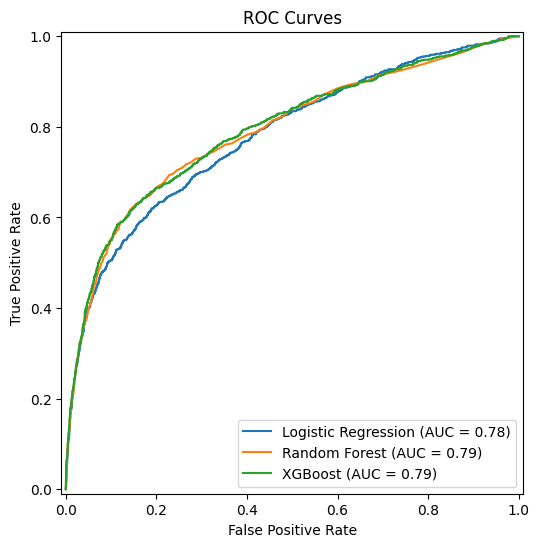

In [27]:
fig, ax = plt.subplots(figsize=(8,6))
RocCurveDisplay.from_predictions(y_val,lr.predict_proba(X_val)[:, 1], ax=ax, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_val,rf.predict_proba(X_val)[:, 1], ax=ax, name="Random Forest")
RocCurveDisplay.from_predictions(y_val,xgb.predict_proba(X_val)[:, 1], ax=ax, name="XGBoost")
ax.set_title("ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
plt.show()

## **Validation Precision-Recall Curves**

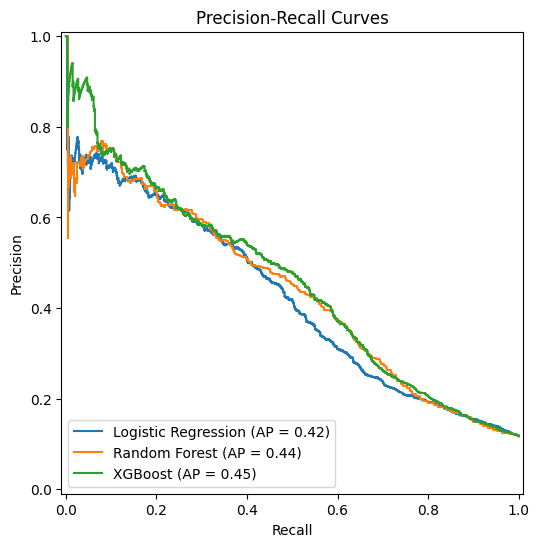

In [28]:
fig, ax = plt.subplots(figsize=(8,6))
PrecisionRecallDisplay.from_predictions(y_val,lr.predict_proba(X_val)[:, 1], ax=ax, name="Logistic Regression")
PrecisionRecallDisplay.from_predictions(y_val,rf.predict_proba(X_val)[:, 1], ax=ax, name="Random Forest")
PrecisionRecallDisplay.from_predictions(y_val,xgb.predict_proba(X_val)[:, 1], ax=ax, name="XGBoost")
ax.set_title("Precision-Recall Curves")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
plt.show()

For both ROC and PR curves, the models' results are pretty similar. XGBoost does just slightly better on both

## **Model Tuning**  
Since XGBoost had the highest ROC-AUC and PR-AUC, we will tune this model.

In [29]:
xgb_parameters = {"n_estimators": [100,200,300,500], "max_depth": [2,3,4,5,6], "learning_rate": [0.01,0.05,0.1,0.2],
                  "subsample": [0.7, 0.8, 0.9, 1.0], "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
                  "min_child_weight": [1,3,5], "reg_lambda":[1,5,10]}
xgb_search = RandomizedSearchCV(estimator=xgb, param_distributions=xgb_parameters, n_iter=25, scoring="average_precision",
                                cv=cv, random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)

print("Best parameters:", xgb_search.best_params_)
print("Best CV PR-AUC:", round(xgb_search.best_score_, 3))

Best parameters: {'subsample': 0.7, 'reg_lambda': 10, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV PR-AUC: 0.44


In [30]:
best_xgb = xgb_search.best_estimator_

In [31]:
best_val_pred = best_xgb.predict(X_val)
best_val_prob = best_xgb.predict_proba(X_val)[:, 1]

best_xgb_val_results = {"Model": "Tuned XGBoost", "Accuracy": accuracy_score(y_val, best_val_pred),
                        "Precision": precision_score(y_val, best_val_pred), "Recall": recall_score(y_val, best_val_pred),
                        "F1": f1_score(y_val, best_val_pred), "ROC-AUC": roc_auc_score(y_val, best_val_prob),
                        "PR-AUC": average_precision_score(y_val, best_val_prob)}
pd.DataFrame([xgb_val_results, best_xgb_val_results]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.893,0.593,0.286,0.386,0.792,0.454
1,Tuned XGBoost,0.899,0.678,0.263,0.379,0.809,0.480


The tuned model performed better for ROC and PR curves, but performed worse on Recall and F1

## **Identify Classification Threshold**

In [32]:
precision, recall, thresholds = precision_recall_curve(y_val, best_val_prob)
threshold_results = pd.DataFrame({"Threshold": thresholds, "Precision": precision[:-1], "Recall": recall[:-1]})
threshold_results["F1"] = 2 * threshold_results["Precision"] * threshold_results["Recall"] / (threshold_results["Precision"] + threshold_results["Recall"])
threshold_results = threshold_results.replace([np.inf, -np.inf], np.nan).dropna()
best_row = threshold_results.loc[threshold_results["F1"].idxmax()]
best_threshold = best_row["Threshold"]
print("Selected threshold:", round(best_threshold, 3))
print(best_row.round(3))

Selected threshold: 0.227
Threshold    0.227
Precision    0.479
Recall       0.533
F1           0.504
Name: 7860, dtype: float64


In [33]:
tuned_val_pred = (best_val_prob >= best_threshold).astype(int)

In [34]:
threshold_val_results = {"Model": "Tuned XGBoost - Selected Threshold", "Threshold": best_threshold, "Accuracy": accuracy_score(y_val, tuned_val_pred),
                         "Precision": precision_score(y_val, tuned_val_pred), "Recall": recall_score(y_val, tuned_val_pred), "F1": f1_score(y_val, tuned_val_pred),
                         "ROC-AUC": roc_auc_score(y_val, best_val_prob), "PR-AUC": average_precision_score(y_val, best_val_prob)}
pd.DataFrame([threshold_val_results]).round(3)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned XGBoost - Selected Threshold,0.227,0.877,0.479,0.533,0.504,0.809,0.48


## **Validation Confusion Matrices**

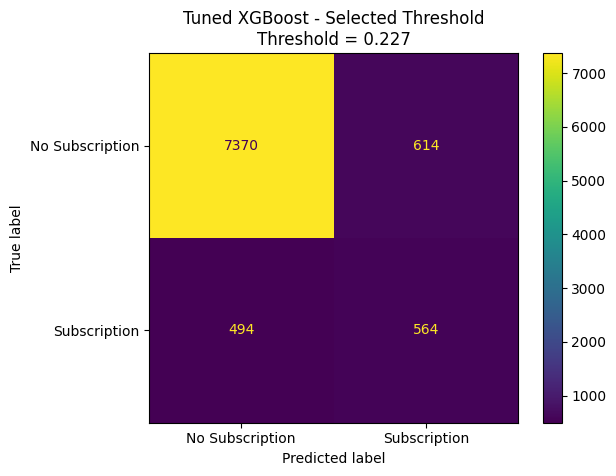

In [35]:
ConfusionMatrixDisplay.from_predictions(y_val, tuned_val_pred, display_labels=["No Subscription", "Subscription"])
plt.title(f"Tuned XGBoost - Selected Threshold\n" f"Threshold = {best_threshold:.3f}")
plt.show()

False Positives: 614  
False Negatives: 494

## **Train Final Model**

In [36]:
X_train_final = np.vstack([X_train, X_val])
y_train_final = np.concatenate([y_train, y_val])
final_model = XGBClassifier(eval_metric = "logloss", random_state = 42, **xgb_search.best_params_)
final_model.fit(X_train_final, y_train_final)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [37]:
test_prob = final_model.predict_proba(X_test)[:,1]
test_pred = (test_prob >= best_threshold).astype(int)

final_test_results = {"Model": "Final Tuned XGBoost", "Threshold": best_threshold, "Accuracy": accuracy_score(y_test, test_pred),
                      "Precision": precision_score(y_test, test_pred), "Recall": recall_score(y_test, test_pred), "F1": f1_score(y_test, test_pred),
                      "ROC-AUC": roc_auc_score(y_test, test_prob), "PR-AUC": average_precision_score(y_test, test_prob)}
pd.DataFrame([final_test_results]).round(3)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Final Tuned XGBoost,0.227,0.88,0.486,0.505,0.495,0.809,0.472


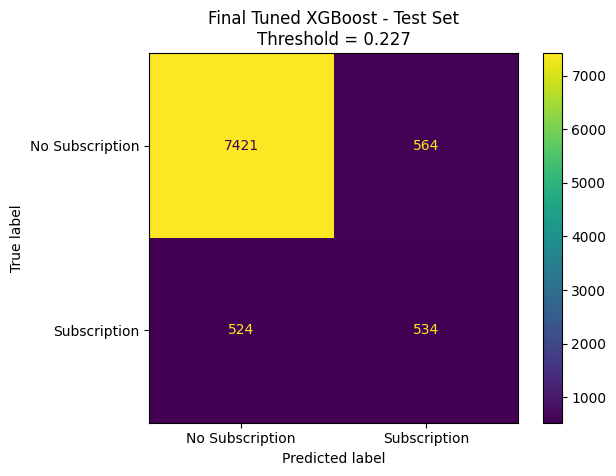

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["No Subscription", "Subscription"])
plt.title(f"Final Tuned XGBoost - Test Set\n" f"Threshold = {best_threshold:.3f}")
plt.show()

False Positives: 564    
False Negatives: 524   
True positives: 534  
True negatives: 7421

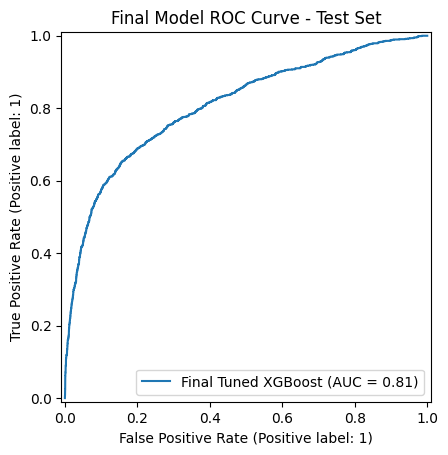

In [39]:
RocCurveDisplay.from_predictions(y_test, test_prob, name="Final Tuned XGBoost")
plt.title("Final Model ROC Curve - Test Set")
plt.show()

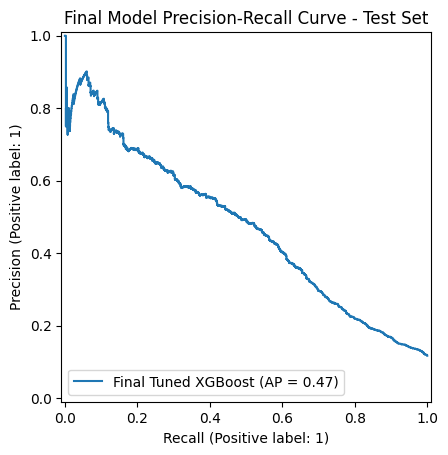

In [40]:
PrecisionRecallDisplay.from_predictions(y_test, test_prob, name="Final Tuned XGBoost")
plt.title("Final Model Precision-Recall Curve - Test Set")
plt.show()

In [41]:
#add feature importance
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": final_model.feature_importances_})
importance_df.sort_values("Importance", ascending=False).head(15)

,Feature,Importance
50,cat__poutcome_success,0.227262
7,num__high_yield_month,0.104460
30,cat__housing_yes,0.064788
51,cat__poutcome_unknown,0.061417
35,cat__contact_unknown,0.060771
29,cat__housing_no,0.034516
42,cat__month_jun,0.028904
39,cat__month_feb,0.026730
33,cat__contact_cellular,0.019936
36,cat__month_apr,0.019641


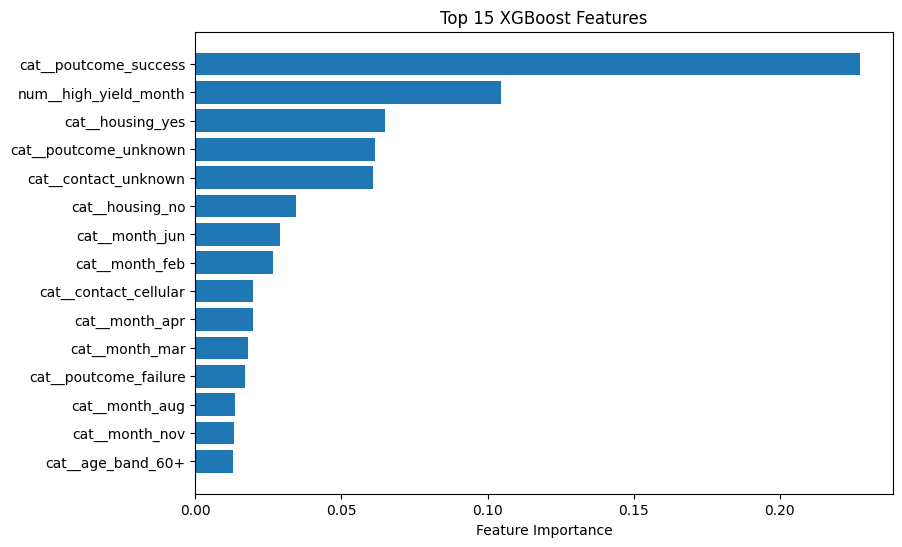

In [42]:
top_features = importance_df.sort_values("Importance", ascending = False).head(15).sort_values("Importance")
plt.figure(figsize=(9,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.title("Top 15 XGBoost Features")
plt.show()